In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("wine.csv")

In [4]:
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,0,US,This tremendous 100% varietal wine hails from ...,Martha's Vineyard,96,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz
1,1,Spain,"Ripe aromas of fig, blackberry and cassis are ...",Carodorum Selecci√≥n Especial Reserva,96,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodr√≠guez
2,2,US,Mac Watson honors the memory of a wine once ma...,Special Selected Late Harvest,96,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley
3,3,US,"This spent 20 months in 30% new French oak, an...",Reserve,96,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi
4,4,France,"This is the top wine from La B√©gude, named af...",La Br√ªlade,95,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la B√©gude


# Exploratory Data Analysis Report

## Wine Dataset

The Wine dataset contains the chemical characteristics of different wine samples. The aim of this analysis is to explore the dataset, identify patterns and relationships between variables, and present the findings using appropriate data visualisations.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1103 non-null   int64  
 1   country      1103 non-null   str    
 2   description  1103 non-null   str    
 3   designation  834 non-null    str    
 4   points       1103 non-null   int64  
 5   price        1046 non-null   float64
 6   province     1103 non-null   str    
 7   region_1     930 non-null    str    
 8   region_2     492 non-null    str    
 9   variety      1103 non-null   str    
 10  winery       1103 non-null   str    
dtypes: float64(1), int64(2), str(8)
memory usage: 94.9 KB


## Dataset Information

The `info()` function provides an overview of the Wine Reviews dataset. The dataset contains **1,103 wine reviews** and **11 variables**, including information about wine ratings, prices, countries, grape varieties, wineries, and regions. The output shows that the `designation`, `price`, `region_1`, and `region_2` columns contain missing values, while the remaining columns are complete. Understanding the structure of the dataset is an important step before cleaning and analysing the data.

In [6]:
df = df.drop(columns=['Unnamed: 0'])

In [7]:
df.describe()

,points,price
count,1103.000000,1046.000000
mean,89.701723,40.242830
std,2.390405,32.588141
min,85.000000,7.000000
25%,88.000000,20.000000
50%,90.000000,31.000000
75%,91.000000,50.000000
max,96.000000,500.000000


## Summary Statistics

The `describe()` function provides descriptive statistics for the numerical variables in the Wine Reviews dataset. The average wine rating is **89.7 points**, indicating that most wines received relatively high ratings. The average wine price is **40.24**, although prices vary considerably, ranging from **7** to **500**. The large difference between the average and maximum price suggests the presence of high-priced outliers. These statistics provide an overview of the dataset before further analysis and visualisation.

In [8]:
df.isnull().sum()

country          0
description      0
designation    269
points           0
price           57
province         0
region_1       173
region_2       611
variety          0
winery           0
dtype: int64

## Handling Missing Values

The dataset contained missing values in the `designation`, `price`, `region_1`, and `region_2` columns. Missing numerical values in the `price` column were replaced with the median price because the median is less affected by extreme values than the mean. Missing categorical values in the `designation`, `region_1`, and `region_2` columns were replaced with the value **"Unknown"**. After cleaning, the dataset contained no missing values and was ready for further analysis.

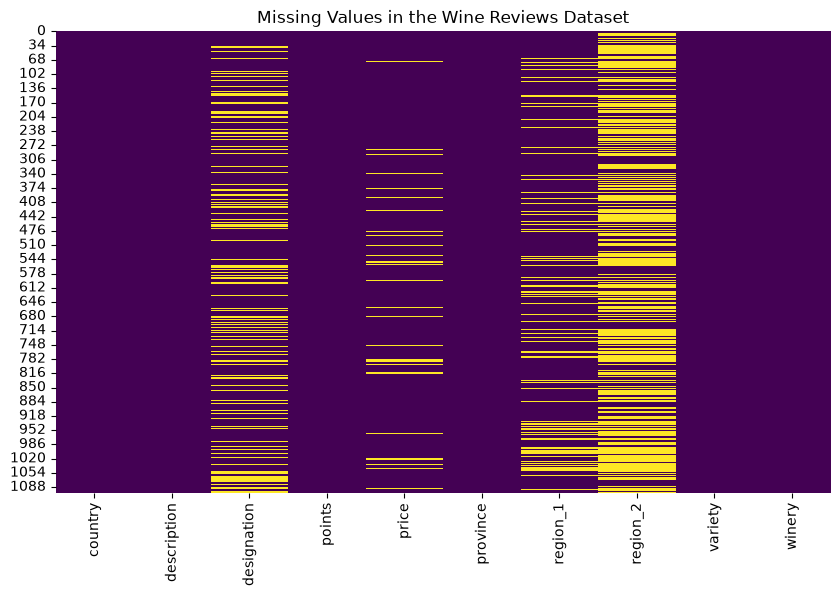

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values in the Wine Reviews Dataset")

plt.show()

In [10]:
df['price'] = df['price'].fillna(df['price'].median())

In [11]:
df['designation'] = df['designation'].fillna('Unknown')
df['region_1'] = df['region_1'].fillna('Unknown')
df['region_2'] = df['region_2'].fillna('Unknown')

In [12]:
df.isnull().sum()

country        0
description    0
designation    0
points         0
price          0
province       0
region_1       0
region_2       0
variety        0
winery         0
dtype: int64

## Handling Missing Values

The Wine Reviews dataset contained missing values in the `designation`, `price`, `region_1`, and `region_2` columns. Missing values in the `price` column were replaced with the median price because the median is less affected by extreme values than the mean. Missing categorical values in the `designation`, `region_1`, and `region_2` columns were replaced with the value **"Unknown"**. After these changes, the dataset contained no missing values and was ready for exploratory data analysis.

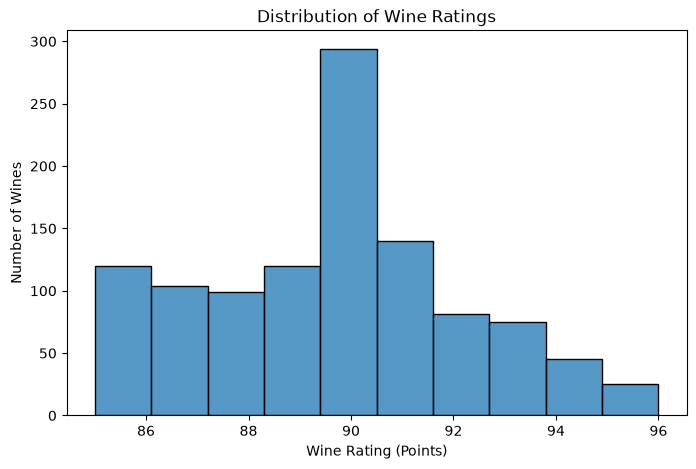

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['points'], bins=10)

plt.title("Distribution of Wine Ratings")
plt.xlabel("Wine Rating (Points)")
plt.ylabel("Number of Wines")

plt.show()

## Distribution of Wine Ratings

The histogram shows the distribution of wine ratings in the dataset. Most wines received ratings between **88 and 91 points**, with relatively few wines receiving the lowest or highest ratings. This indicates that the dataset is made up mainly of highly rated wines.

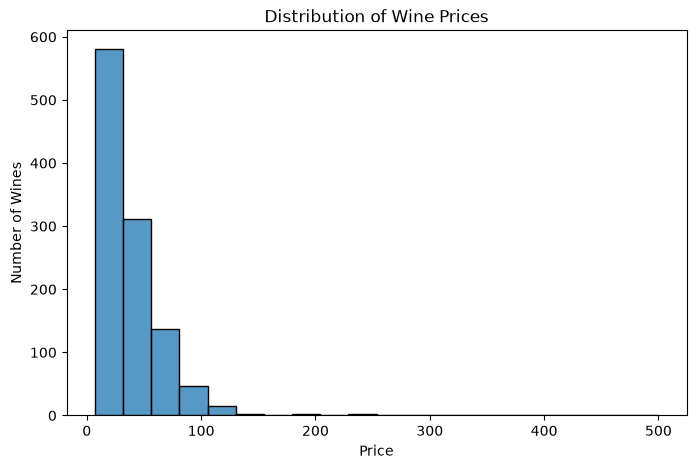

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=20)

plt.title("Distribution of Wine Prices")
plt.xlabel("Price")
plt.ylabel("Number of Wines")

plt.show()

## Distribution of Wine Prices

The histogram shows that most wines are priced at the lower end of the price range, while only a small number of wines are very expensive. The distribution is positively skewed, with a long tail extending towards higher prices. This indicates the presence of high-priced wines that are less common in the dataset.

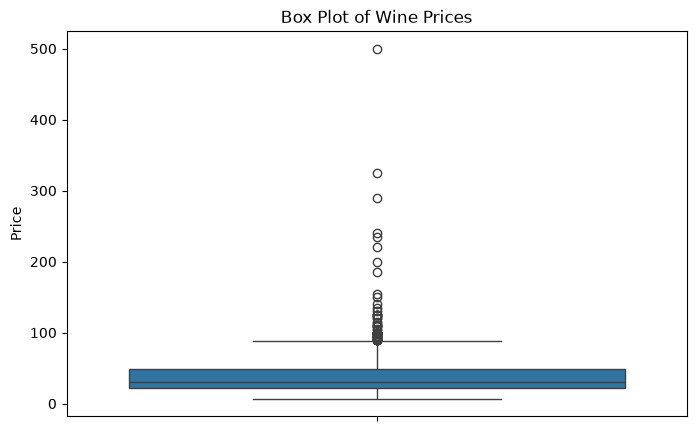

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['price'])

plt.title("Box Plot of Wine Prices")
plt.ylabel("Price")

plt.show()

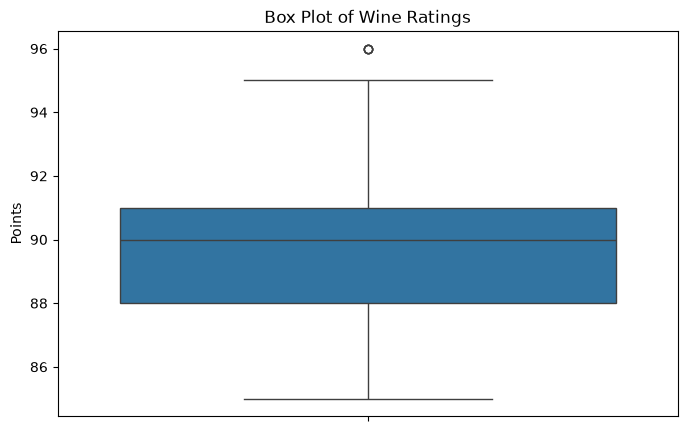

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['points'])

plt.title("Box Plot of Wine Ratings")
plt.ylabel("Points")

plt.show()

## Box Plot Analysis

The box plots provide a summary of the distribution of wine prices and ratings. The price box plot shows several high-value outliers, indicating that a small number of wines are significantly more expensive than the majority. In contrast, the ratings box plot shows that wine ratings are concentrated within a narrow range, with relatively little variation. These visualisations confirm the findings observed in the histograms.

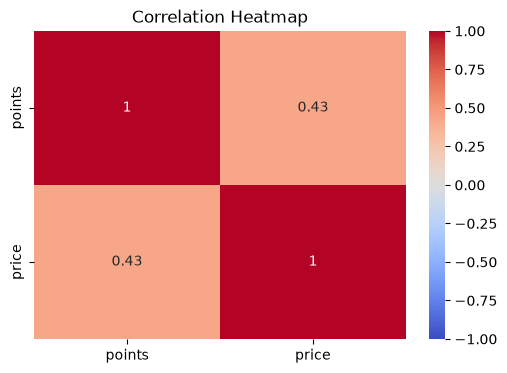

In [17]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation = numeric_df.corr()

# Create the heatmap
plt.figure(figsize=(6,4))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Analysis

The correlation heatmap illustrates the relationship between the numerical variables in the Wine Reviews dataset. The analysis shows the strength and direction of the relationship between wine ratings (`points`) and prices (`price`). A positive correlation indicates that wines with higher prices tend to receive higher ratings, although the relationship is not perfect. The heatmap provides a useful summary of the numerical relationships within the dataset.

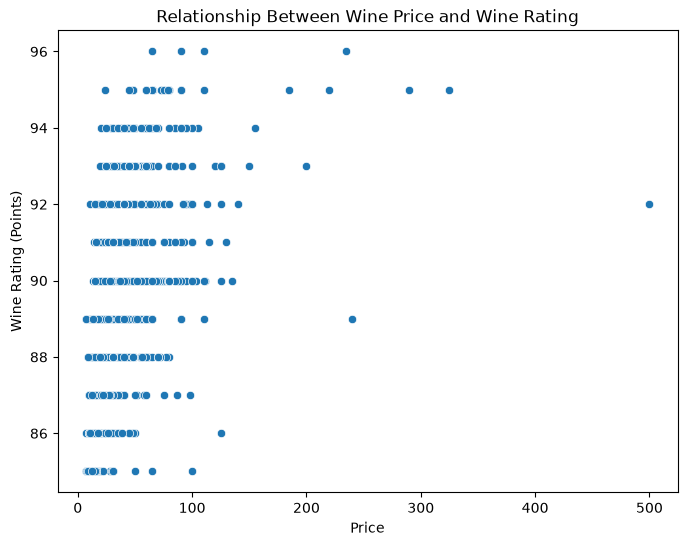

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='price', y='points', data=df)

plt.title("Relationship Between Wine Price and Wine Rating")
plt.xlabel("Price")
plt.ylabel("Wine Rating (Points)")

plt.show()

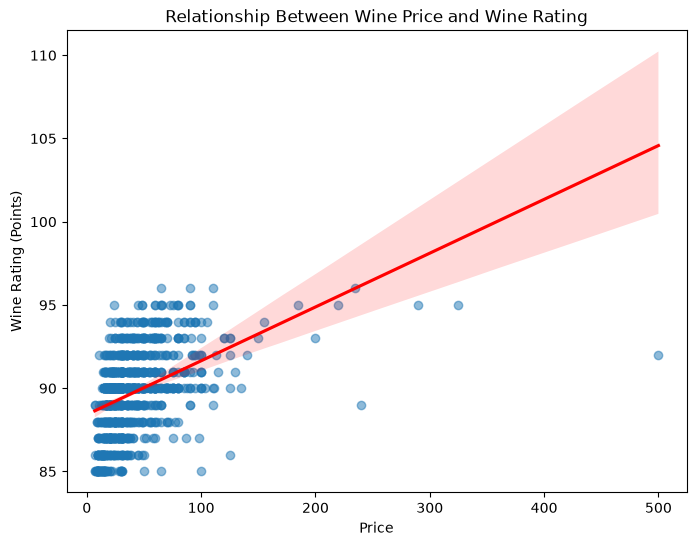

In [19]:
plt.figure(figsize=(8,6))

sns.regplot(x='price',
            y='points',
            data=df,
            scatter_kws={'alpha':0.5},
            line_kws={'color':'red'})

plt.title("Relationship Between Wine Price and Wine Rating")
plt.xlabel("Price")
plt.ylabel("Wine Rating (Points)")

plt.show()

## Relationship Between Wine Price and Ratings

The scatter plot examines the relationship between wine prices and ratings. Each point represents an individual wine. The trend line indicates that there is a positive relationship between price and rating, suggesting that more expensive wines generally receive slightly higher ratings. However, the spread of the points also shows that price alone does not determine wine quality, as some lower-priced wines receive high ratings while some expensive wines receive average ratings.

# Key Findings

Based on the exploratory data analysis of the Wine Reviews dataset, the following key findings were identified:

### 1. Wine Ratings
Most wines in the dataset received ratings between **89 and 91 points**, with **90 points** being the most common rating. This indicates that the dataset is largely made up of highly rated wines.

### 2. Wine Prices
Most wines were priced below **50**, while only a small number of wines were highly priced. The price distribution was positively skewed, indicating the presence of several expensive wines.

### 3. Missing Values
The dataset contained missing values in the `designation`, `price`, `region_1`, and `region_2` columns. These missing values were handled by replacing missing prices with the median value and replacing missing categorical values with **"Unknown"**.

### 4. Price Outliers
The box plot revealed several high-priced outliers. These wines were considerably more expensive than the majority of wines in the dataset and contributed to the positive skewness of the price distribution.

### 5. Relationship Between Price and Rating
The correlation heatmap and scatter plot showed a positive relationship between wine prices and ratings. While higher-priced wines generally tended to receive higher ratings, there were also affordable wines with excellent ratings and expensive wines with average ratings. This suggests that price alone does not determine wine quality.

# Conclusion

This Exploratory Data Analysis (EDA) examined the Wine Reviews dataset to better understand the characteristics of the wines and identify patterns within the data. The dataset was first explored to understand its structure, and missing values were identified and appropriately handled to ensure the quality of the analysis.

The visualisations showed that most wines in the dataset received high ratings, with the majority scoring between **89 and 91 points**. Most wines were also priced below **50**, although a small number of premium wines were considerably more expensive. The box plots confirmed the presence of these high-priced outliers.

The correlation analysis and scatter plot indicated a positive relationship between wine price and wine rating. While higher-priced wines generally tended to receive higher ratings, the relationship was not strong enough to conclude that price alone determines wine quality. Several affordable wines also received excellent ratings.

Overall, the exploratory data analysis provided valuable insights into the Wine Reviews dataset and demonstrated how descriptive statistics and data visualisations can be used to understand data, identify trends, detect outliers, and support data-driven decision-making.